# Telecom Revenue Protection & Customer Retention Intelligence System

# PROBLEM STATEMENT 

Telecom companies are facing high customer churn due to competitive pricing, poor service experience, customer's complain  and changing user behavior. Losing customers leads to significant revenue loss and increased acquisition costs.

# OBJECTIVES 

PRIMARY OBJECTIVE 

To develop a machine learning model that predicts the probability of customer churn within a defined future time window (e.g., next 30/60 days).

SECONDARY OBJECTIVE 

Identify key factors driving customer churn

Segment customers based on churn risk levels (high, medium, low)

Enable targeted retention strategies for high-risk customers

Improve customer retention rate and reduce revenue loss

In [141]:
import pandas as pd 
import numpy as np 
import scipy as sc 
import seaborn as sns 
import matplotlib.pyplot as plt 
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier

In [142]:
df = pd.read_csv("Customer Churn.csv")

# ABOUT FEATURE 

Anonymous Customer ID

Call Failures: number of call failures

Complains: binary (0: No complaint, 1: complaint)

Subscription Length: total months of subscription

Charge Amount: Ordinal attribute (0: lowest amount, 9: highest amount)

Seconds of Use: total seconds of calls

Frequency of use: total number of calls

Frequency of SMS: total number of text messages

Distinct Called Numbers: total number of distinct phone calls 

Age Group: ordinal attribute (1: younger age, 5: older age)

Tariff Plan: binary (1: Pay as you go, 2: contractual)

Status: binary (1: active, 2: non-active)

Churn: binary (1: churn, 0: non-churn) - Class label

Customer Value: The calculated value of customer

# BASIC DATA UNDERSTANDING 

In [143]:
df.rename(columns={'Customer Value' : 'CLV'}, inplace = True)

In [144]:
df.shape

(3150, 14)

In [145]:
df.head()

,Call Failure,Complains,Subscription Length,Charge Amount,Seconds of Use,Frequency of use,Frequency of SMS,Distinct Called Numbers,Age Group,Tariff Plan,Status,Age,CLV,Churn
0,8,0,38,0,4370,71,5,17,3,1,1,30,197.640,0
1,0,0,39,0,318,5,7,4,2,1,2,25,46.035,0
2,10,0,37,0,2453,60,359,24,3,1,1,30,1536.520,0
3,10,0,38,0,4198,66,1,35,1,1,1,15,240.020,0
4,3,0,38,0,2393,58,2,33,1,1,1,15,145.805,0


In [146]:
df.tail()

,Call Failure,Complains,Subscription Length,Charge Amount,Seconds of Use,Frequency of use,Frequency of SMS,Distinct Called Numbers,Age Group,Tariff Plan,Status,Age,CLV,Churn
3145,21,0,19,2,6697,147,92,44,2,2,1,25,721.98,0
3146,17,0,17,1,9237,177,80,42,5,1,1,55,261.21,0
3147,13,0,18,4,3157,51,38,21,3,1,1,30,280.32,0
3148,7,0,11,2,4695,46,222,12,3,1,1,30,1077.64,0
3149,8,1,11,2,1792,25,7,9,3,1,1,30,100.68,1


In [147]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3150 entries, 0 to 3149
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Call  Failure            3150 non-null   int64  
 1   Complains                3150 non-null   int64  
 2   Subscription  Length     3150 non-null   int64  
 3   Charge  Amount           3150 non-null   int64  
 4   Seconds of Use           3150 non-null   int64  
 5   Frequency of use         3150 non-null   int64  
 6   Frequency of SMS         3150 non-null   int64  
 7   Distinct Called Numbers  3150 non-null   int64  
 8   Age Group                3150 non-null   int64  
 9   Tariff Plan              3150 non-null   int64  
 10  Status                   3150 non-null   int64  
 11  Age                      3150 non-null   int64  
 12  CLV                      3150 non-null   float64
 13  Churn                    3150 non-null   int64  
dtypes: float64(1), int64(13)

In [148]:
df.isnull().sum()

Call  Failure              0
Complains                  0
Subscription  Length       0
Charge  Amount             0
Seconds of Use             0
Frequency of use           0
Frequency of SMS           0
Distinct Called Numbers    0
Age Group                  0
Tariff Plan                0
Status                     0
Age                        0
CLV                        0
Churn                      0
dtype: int64

In [149]:
df.duplicated().sum()

np.int64(300)

In [150]:
df.corr()

,Call Failure,Complains,Subscription Length,Charge Amount,Seconds of Use,Frequency of use,Frequency of SMS,Distinct Called Numbers,Age Group,Tariff Plan,Status,Age,CLV,Churn
Call Failure,1.000000,0.152879,0.169737,0.589028,0.501607,0.573349,-0.022282,0.504058,0.050406,0.192285,-0.114645,0.041758,0.121225,-0.008987
Complains,0.152879,1.000000,-0.020286,-0.033948,-0.104952,-0.090774,-0.111633,-0.058199,0.019976,0.001140,0.271405,0.003298,-0.132895,0.532053
Subscription Length,0.169737,-0.020286,1.000000,0.078789,0.124618,0.106534,0.076318,0.092009,0.021453,-0.159680,0.142841,-0.002430,0.109565,-0.032588
Charge Amount,0.589028,-0.033948,0.078789,1.000000,0.446738,0.379096,0.091533,0.415198,0.279679,0.324232,-0.356269,0.278955,0.169428,-0.202305
Seconds of Use,0.501607,-0.104952,0.124618,0.446738,1.000000,0.946489,0.102123,0.676536,0.020060,0.133593,-0.460618,0.020843,0.415087,-0.298935
Frequency of use,0.573349,-0.090774,0.106534,0.379096,0.946489,1.000000,0.100019,0.736114,-0.032544,0.206452,-0.454752,-0.028350,0.401572,-0.303337
Frequency of SMS,-0.022282,-0.111633,0.076318,0.091533,0.102123,0.100019,1.000000,0.079650,-0.053719,0.195686,-0.296164,-0.092798,0.924877,-0.220754
Distinct Called Numbers,0.504058,-0.058199,0.092009,0.415198,0.676536,0.736114,0.079650,1.000000,0.020941,0.172079,-0.413039,0.051037,0.284807,-0.278867
Age Group,0.050406,0.019976,0.021453,0.279679,0.020060,-0.032544,-0.053719,0.020941,1.000000,-0.150593,0.002506,0.960758,-0.183481,-0.014550
Tariff Plan,0.192285,0.001140,-0.159680,0.324232,0.133593,0.206452,0.195686,0.172079,-0.150593,1.000000,-0.164143,-0.119426,0.252298,-0.105853


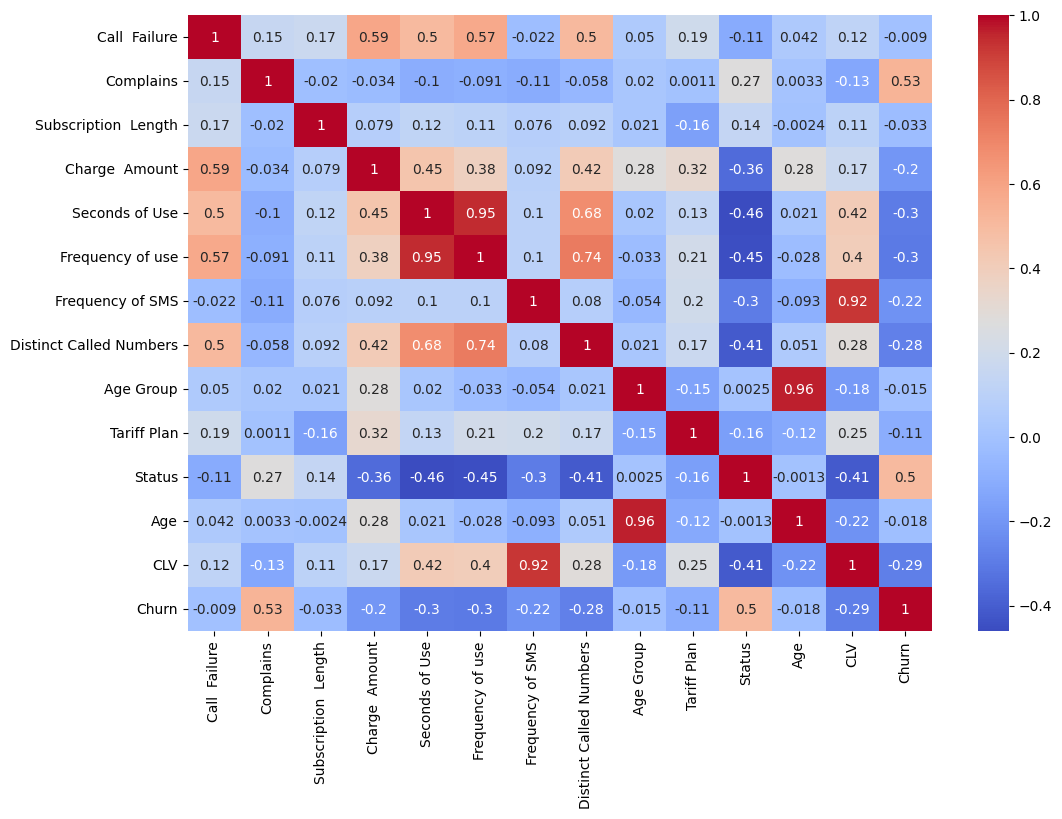

In [151]:

import seaborn as sns
import matplotlib.pyplot as plt

numeric_df = df.select_dtypes(include=['number'])

plt.figure(figsize=(12,8))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.show()

OBSERVATION BY CORRELATION 

The observation that features such as Call Failure, Subscription Length, Charge Amount, Seconds of Use, Frequency of Use, Frequency of SMS, Distinct Called Numbers, Age Group, Tariff Plan, Status, Age, and CLV all show a negative correlation with churn indicates that, in general, as the values of these features increase, the likelihood of a customer churning tends to decrease. In other words, customers who are more engaged, have longer subscriptions, higher usage, and greater value (such as higher CLV) are less likely to leave the telecom service. However, if the correlation values are very close to zero, this suggests that the relationship between these features and churn is weak, meaning no single feature strongly influences churn on its own. Therefore, while the negative direction aligns with expected business behavior (more active customers churn less), these features should be considered collectively and through modeling rather than relying solely on individual correlations for prediction.

# ANALYZING FEATURE FOR CHURN ( FEATURE SELECTION ) 

analyzing feature whcih affect churn by diffrebt diffrent method beacuse by correlation its become difficult to analyze 

Negative → reduces churn 

Positive → increases churn

Close to 0 → weak 

In [152]:
corr = df.corr(numeric_only=True)

# correlation with churn
corr['Churn'].sort_values()

Frequency of use          -0.303337
Seconds of Use            -0.298935
CLV                       -0.289144
Distinct Called Numbers   -0.278867
Frequency of SMS          -0.220754
Charge  Amount            -0.202305
Tariff Plan               -0.105853
Subscription  Length      -0.032588
Age                       -0.017705
Age Group                 -0.014550
Call  Failure             -0.008987
Status                     0.498976
Complains                  0.532053
Churn                      1.000000
Name: Churn, dtype: float64

BY SPECIFIC FEATURE 

MORE DIFFRENCE IN VALUES (mean) STRONG FEATURE 

LESS DIFFRENCE IN VALUES (mean) WEAK FEATURE 

 customer who did NOT churn (0)

Customers who churned (1)

If the difference is large, it generally means that feature strongly influences churn and has good predictive power for separating churned vs non-churned customers.

here we done bivariate analysis of each feature or one which derive churn , by help of this we can easily identify (feature v/s churn & non churn ) big diffrence creates high churn chances or derive churn much  

In [153]:
df.groupby('Churn')['Subscription  Length'].mean()


Churn
0    32.662524
1    31.894949
Name: Subscription  Length, dtype: float64

In [154]:
df.groupby('Churn')['Charge  Amount'].mean() # strong 


Churn
0    1.075706
1    0.230303
Name: Charge  Amount, dtype: float64

In [155]:
df.groupby('Churn')['Status'].mean() 

Churn
0    1.155179
1    1.747475
Name: Status, dtype: float64

In [156]:
df.groupby('Churn')['Frequency of use'].mean() # strong feature 

Churn
0    76.979284
1    29.133333
Name: Frequency of use, dtype: float64

In [157]:
df.groupby('Churn')['Seconds of Use'].mean() # strong 

Churn
0    5014.224105
1    1566.632323
Name: Seconds of Use, dtype: float64

In [158]:
df.groupby('Churn')['Complains'].mean()  # strong feature 

Churn
0    0.015443
1    0.404040
Name: Complains, dtype: float64

In [159]:
df.groupby('Churn')['Call  Failure'].mean()

Churn
0    7.656121
1    7.476768
Name: Call  Failure, dtype: float64

In [160]:
df.groupby('Churn')['Status'].mean()

Churn
0    1.155179
1    1.747475
Name: Status, dtype: float64

In [161]:
df.groupby('Churn')['CLV'].mean() # strong feature 

Churn
0    535.511501
1    124.811414
Name: CLV, dtype: float64

In [162]:
df.groupby('Churn')['Age'].mean()

Churn
0    31.065913
1    30.636364
Name: Age, dtype: float64

In [163]:
df.groupby('Churn')['Distinct Called Numbers'].mean() # strong feature 

Churn
0    25.582674
1    12.391919
Name: Distinct Called Numbers, dtype: float64

In [164]:
df.groupby('Churn')['Tariff Plan'].mean()

Churn
0    1.090019
1    1.012121
Name: Tariff Plan, dtype: float64

In [165]:
df['usage_per_month'] = df['Frequency of use'] / df['Subscription  Length']

In [166]:
df.groupby('Churn')['usage_per_month'].mean() #strong 

Churn
0    2.604804
1    1.037510
Name: usage_per_month, dtype: float64

In [167]:
df['sms_per_usage'] = (
    df['Frequency of SMS'] /
    (df['Frequency of use'] + 1)
)

In [168]:
df.groupby('Churn')['sms_per_usage'].mean() # strong feature 

Churn
0    1.653558
1    0.749027
Name: sms_per_usage, dtype: float64

In [169]:
df['revenue_per_usage'] = (
    df['Charge  Amount'] /
    (df['Frequency of use'] + 1)
)

In [170]:
df.groupby('Churn')['revenue_per_usage'].mean()  # strong feature 

Churn
0    0.016780
1    0.009043
Name: revenue_per_usage, dtype: float64

In [171]:
df['complaint_ratio'] = (
    df['Complains'] /
    (df['Frequency of use'] + 1)
)

In [172]:
df.groupby('Churn')['complaint_ratio'].mean() # strong 

Churn
0    0.000181
1    0.046992
Name: complaint_ratio, dtype: float64

In [173]:
df['call_failure_rate'] = (
    df['Call  Failure'] /
    (df['Frequency of use'] + 1)
)

In [174]:
df.groupby('Churn')['call_failure_rate'].mean() #strong 

Churn
0    0.113432
1    0.228909
Name: call_failure_rate, dtype: float64

In [175]:
df['loyalty_score'] = (
    df['Subscription  Length'] *
    df['Frequency of use']
)

In [176]:
df.groupby('Churn')['loyalty_score'].mean() # strong feature 

Churn
0    2564.509605
1     962.747475
Name: loyalty_score, dtype: float64

import pandas as pd

# create 5 bins (you can change number)
df['CLV'] = pd.cut(df['CLV'], bins=5, labels=False)

print(df[['CLV', 'CLV_bins']].head())

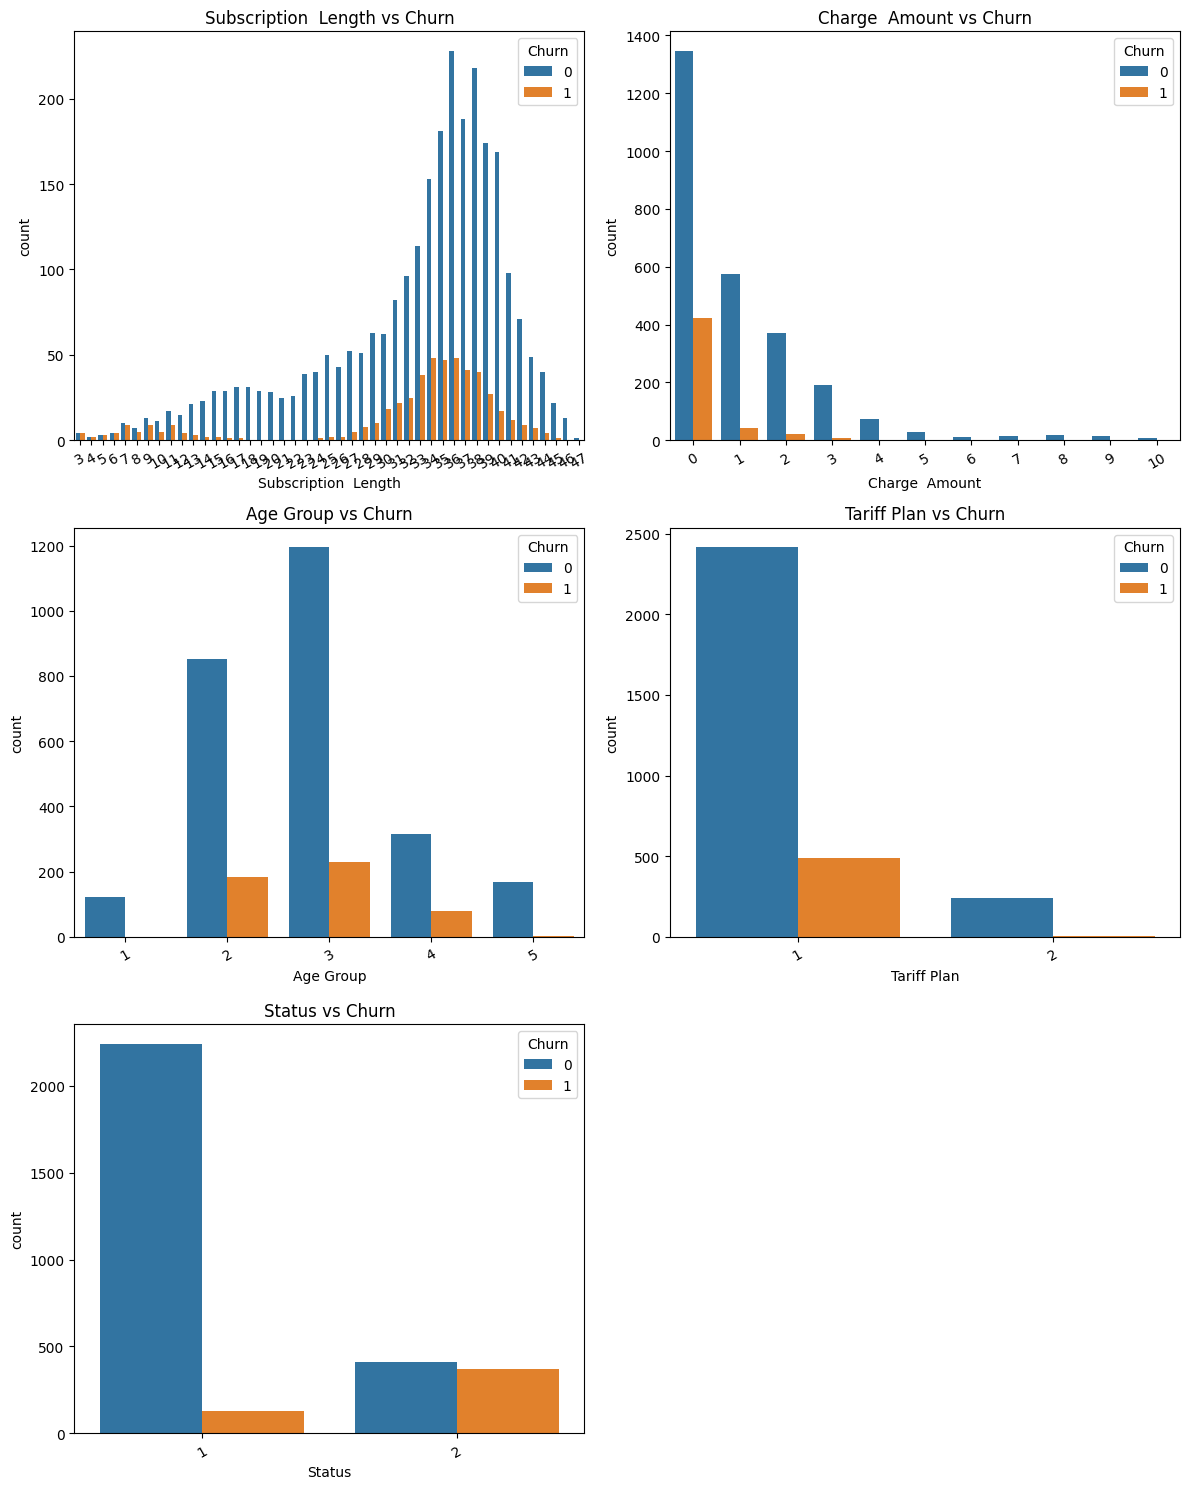

In [177]:
import seaborn as sns
import matplotlib.pyplot as plt
import math

# 👉 Add your columns here (flexible)
cat_cols = ['Subscription  Length', 'Charge  Amount','Age Group','Tariff Plan','Status',]

# grid setup
n_cols = 2   # number of plots per row
n_rows = math.ceil(len(cat_cols) / n_cols)

plt.figure(figsize=(12, 5 * n_rows))

for i, col in enumerate(cat_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.countplot(x=col, hue='Churn', data=df)
    plt.title(f'{col} vs Churn')
    plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

Segmentation Analysis

# create bins
df['tenure_group'] = pd.cut(df['Subscription  Length'], bins=[0,6,12,24,60])



# churn rate per group
df.groupby('tenure_group')['Churn'].mean()

The sudden decline in churn for customers with 12–24 months of subscription likely reflects a stabilization phase, where customers who remain beyond the initial trial period develop stronger service dependence and loyalty, while early churn-prone customers have already exited the system.

df.groupby('tenure_group').size()

df[df['tenure_group'].astype(str) == '(12, 24]'].groupby('Churn').mean(numeric_only=True)

BY SHAP VALUES 

SHAP value = contribution of each feature in pushing prediction up or down

Direction meaning

Positive SHAP (+) → pushes prediction higher (towards churn)

Negative SHAP (-) → pushes prediction lower (away from churn)

import shap

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X)

shap.summary_plot(shap_values, X)

In [178]:
df.skew(numeric_only=True)

Call  Failure               1.089752
Complains                   3.187956
Subscription  Length       -1.300015
Charge  Amount              2.584868
Seconds of Use              1.321943
Frequency of use            1.144166
Frequency of SMS            1.974142
Distinct Called Numbers     1.029402
Age Group                   0.473642
Tariff Plan                 3.154514
Status                      1.166046
Age                         1.248452
CLV                         1.427292
Churn                       1.885063
usage_per_month             2.480055
sms_per_usage               5.213255
revenue_per_usage          13.592528
complaint_ratio            13.152346
call_failure_rate           2.659840
loyalty_score               1.288675
dtype: float64

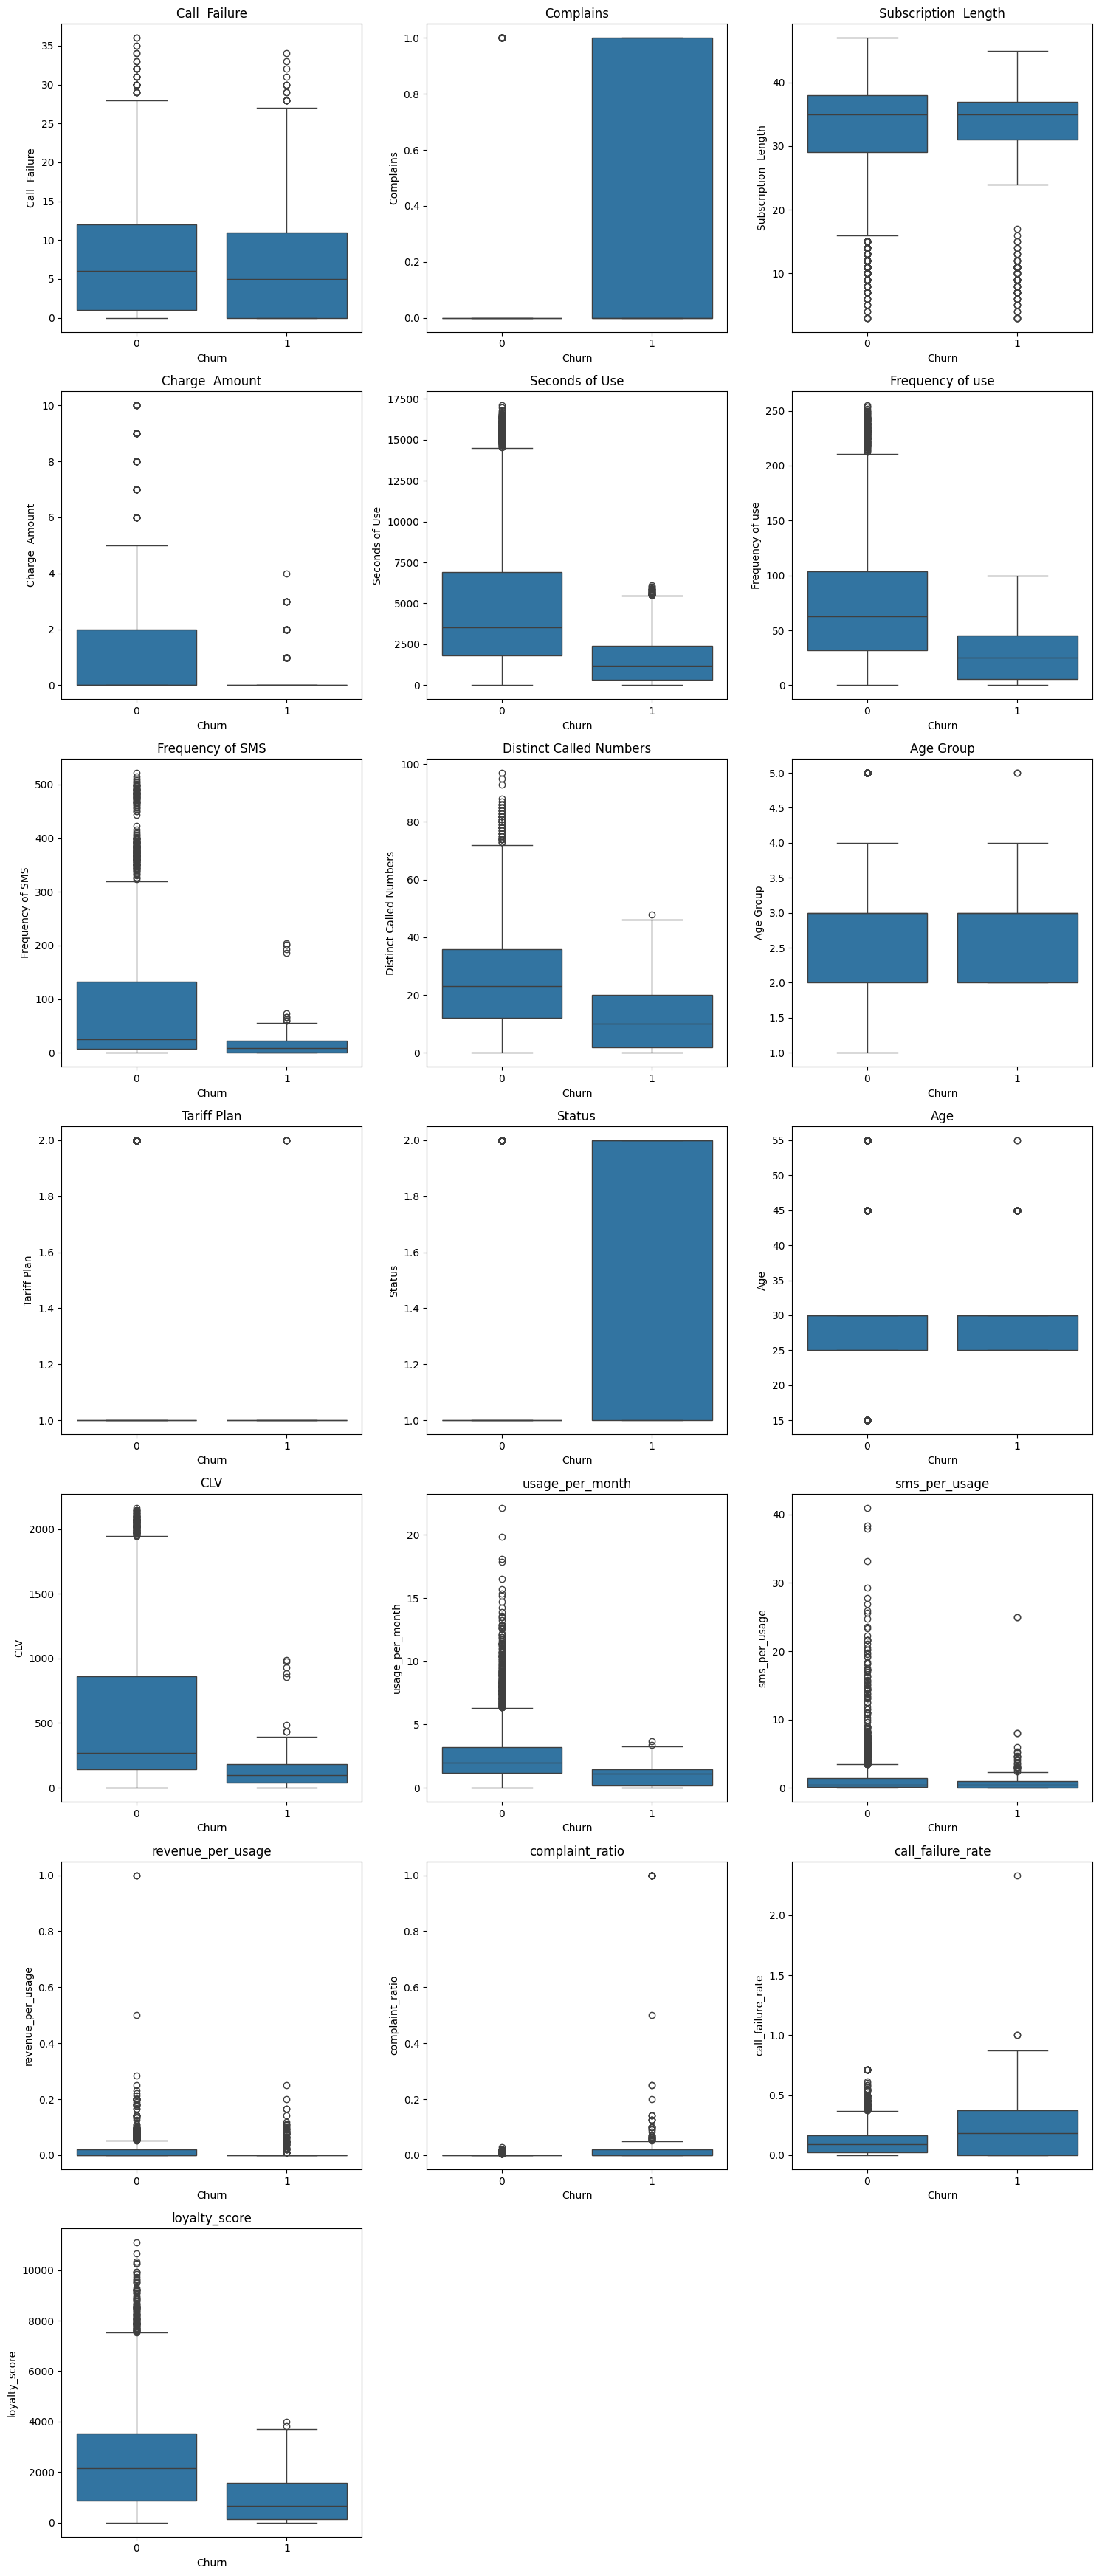

In [179]:

import math

num_cols = df.select_dtypes(include=['int64', 'float64']).columns.drop('Churn')

n_cols = 3
n_rows = math.ceil(len(num_cols)/n_cols)

plt.figure(figsize=(15, 5*n_rows))

for i, col in enumerate(num_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.boxplot(x='Churn', y=col, data=df)
    plt.title(col)

plt.tight_layout()
plt.show()

In [180]:
df.kurt(numeric_only=True)

Call  Failure                0.906821
Complains                    8.168250
Subscription  Length         1.215842
Charge  Amount               8.854358
Seconds of Use               0.993676
Frequency of use             0.820125
Frequency of SMS             3.258540
Distinct Called Numbers      1.359990
Age Group                    0.205135
Tariff Plan                  7.956007
Status                      -0.640743
Age                          1.234350
CLV                          1.224497
Churn                        1.554447
usage_per_month              8.868586
sms_per_usage               37.587085
revenue_per_usage          288.176428
complaint_ratio            175.891614
call_failure_rate           18.606245
loyalty_score                1.456951
dtype: float64

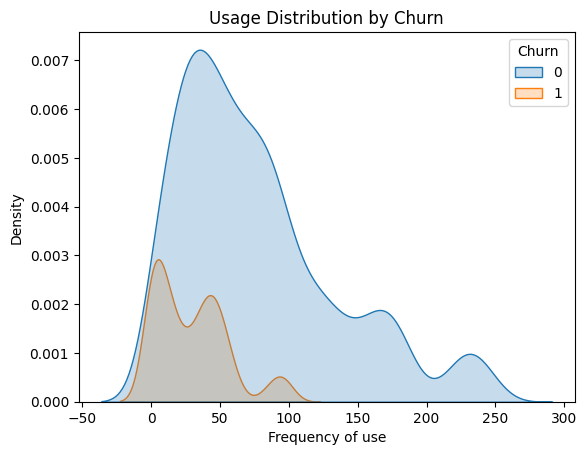

In [181]:

sns.kdeplot(data=df, x='Frequency of use', hue='Churn', fill=True)
plt.title("Usage Distribution by Churn")
plt.show()

From it, we understand which value ranges of the feature are more associated with churn (where the curves differ or overlap less).

In [182]:
df.head()

,Call Failure,Complains,Subscription Length,Charge Amount,Seconds of Use,Frequency of use,Frequency of SMS,Distinct Called Numbers,Age Group,Tariff Plan,Status,Age,CLV,Churn,usage_per_month,sms_per_usage,revenue_per_usage,complaint_ratio,call_failure_rate,loyalty_score
0,8,0,38,0,4370,71,5,17,3,1,1,30,197.640,0,1.868421,0.069444,0.0,0.0,0.111111,2698
1,0,0,39,0,318,5,7,4,2,1,2,25,46.035,0,0.128205,1.166667,0.0,0.0,0.000000,195
2,10,0,37,0,2453,60,359,24,3,1,1,30,1536.520,0,1.621622,5.885246,0.0,0.0,0.163934,2220
3,10,0,38,0,4198,66,1,35,1,1,1,15,240.020,0,1.736842,0.014925,0.0,0.0,0.149254,2508
4,3,0,38,0,2393,58,2,33,1,1,1,15,145.805,0,1.526316,0.033898,0.0,0.0,0.050847,2204


In [183]:
df.describe(include='number')

,Call Failure,Complains,Subscription Length,Charge Amount,Seconds of Use,Frequency of use,Frequency of SMS,Distinct Called Numbers,Age Group,Tariff Plan,Status,Age,CLV,Churn,usage_per_month,sms_per_usage,revenue_per_usage,complaint_ratio,call_failure_rate,loyalty_score
count,3150.000000,3150.000000,3150.000000,3150.000000,3150.000000,3150.000000,3150.000000,3150.000000,3150.000000,3150.000000,3150.000000,3150.000000,3150.000000,3150.000000,3150.000000,3150.000000,3150.000000,3150.000000,3150.000000,3150.000000
mean,7.627937,0.076508,32.541905,0.942857,4472.459683,69.460635,73.174921,23.509841,2.826032,1.077778,1.248254,30.998413,470.972916,0.157143,2.358515,1.511417,0.015565,0.007537,0.131579,2312.804127
std,7.263886,0.265851,8.573482,1.521072,4197.908687,57.413308,112.237560,17.217337,0.892555,0.267864,0.432069,8.831095,517.015433,0.363993,2.346045,3.236625,0.042244,0.072568,0.148336,2063.532511
min,0.000000,0.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,15.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,0.000000,30.000000,0.000000,1391.250000,27.000000,6.000000,10.000000,2.000000,1.000000,1.000000,25.000000,113.801250,0.000000,0.973151,0.080000,0.000000,0.000000,0.021564,703.250000
50%,6.000000,0.000000,35.000000,0.000000,2990.000000,54.000000,21.000000,21.000000,3.000000,1.000000,1.000000,30.000000,228.480000,0.000000,1.716117,0.459999,0.000000,0.000000,0.094859,1832.500000
75%,12.000000,0.000000,38.000000,1.000000,6478.250000,95.000000,87.000000,34.000000,3.000000,1.000000,1.000000,30.000000,788.388750,0.000000,2.866216,1.298529,0.018648,0.000000,0.183673,3240.000000
max,36.000000,1.000000,47.000000,10.000000,17090.000000,255.000000,522.000000,97.000000,5.000000,2.000000,2.000000,55.000000,2165.280000,1.000000,22.142857,41.000000,1.000000,1.000000,2.333333,11086.000000


In [184]:
df.columns

Index(['Call  Failure', 'Complains', 'Subscription  Length', 'Charge  Amount',
       'Seconds of Use', 'Frequency of use', 'Frequency of SMS',
       'Distinct Called Numbers', 'Age Group', 'Tariff Plan', 'Status', 'Age',
       'CLV', 'Churn', 'usage_per_month', 'sms_per_usage', 'revenue_per_usage',
       'complaint_ratio', 'call_failure_rate', 'loyalty_score'],
      dtype='object')

<Axes: xlabel='CLV', ylabel='Density'>

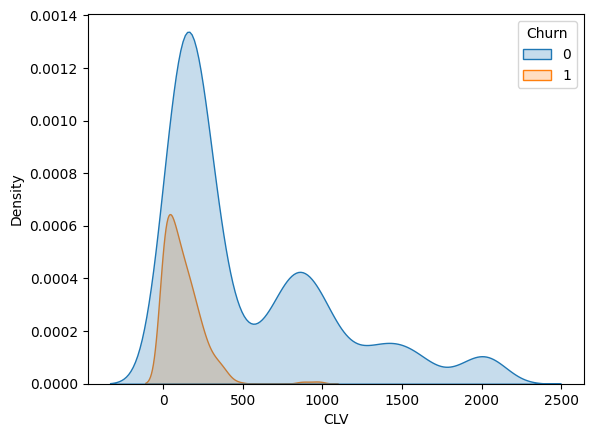

In [185]:
sns.kdeplot(data=df, x='CLV', hue='Churn', fill=True)

<Axes: xlabel='Age Group', ylabel='count'>

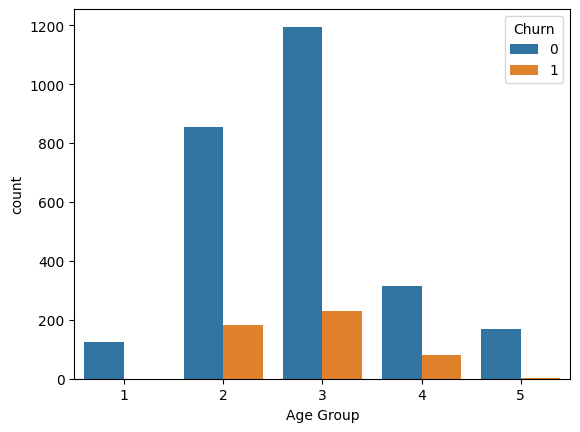

In [186]:
sns.countplot(x='Age Group', hue='Churn', data=df)

In [187]:
df.head()

,Call Failure,Complains,Subscription Length,Charge Amount,Seconds of Use,Frequency of use,Frequency of SMS,Distinct Called Numbers,Age Group,Tariff Plan,Status,Age,CLV,Churn,usage_per_month,sms_per_usage,revenue_per_usage,complaint_ratio,call_failure_rate,loyalty_score
0,8,0,38,0,4370,71,5,17,3,1,1,30,197.640,0,1.868421,0.069444,0.0,0.0,0.111111,2698
1,0,0,39,0,318,5,7,4,2,1,2,25,46.035,0,0.128205,1.166667,0.0,0.0,0.000000,195
2,10,0,37,0,2453,60,359,24,3,1,1,30,1536.520,0,1.621622,5.885246,0.0,0.0,0.163934,2220
3,10,0,38,0,4198,66,1,35,1,1,1,15,240.020,0,1.736842,0.014925,0.0,0.0,0.149254,2508
4,3,0,38,0,2393,58,2,33,1,1,1,15,145.805,0,1.526316,0.033898,0.0,0.0,0.050847,2204


In [188]:
df.head()

,Call Failure,Complains,Subscription Length,Charge Amount,Seconds of Use,Frequency of use,Frequency of SMS,Distinct Called Numbers,Age Group,Tariff Plan,Status,Age,CLV,Churn,usage_per_month,sms_per_usage,revenue_per_usage,complaint_ratio,call_failure_rate,loyalty_score
0,8,0,38,0,4370,71,5,17,3,1,1,30,197.640,0,1.868421,0.069444,0.0,0.0,0.111111,2698
1,0,0,39,0,318,5,7,4,2,1,2,25,46.035,0,0.128205,1.166667,0.0,0.0,0.000000,195
2,10,0,37,0,2453,60,359,24,3,1,1,30,1536.520,0,1.621622,5.885246,0.0,0.0,0.163934,2220
3,10,0,38,0,4198,66,1,35,1,1,1,15,240.020,0,1.736842,0.014925,0.0,0.0,0.149254,2508
4,3,0,38,0,2393,58,2,33,1,1,1,15,145.805,0,1.526316,0.033898,0.0,0.0,0.050847,2204


In [189]:
df.columns

Index(['Call  Failure', 'Complains', 'Subscription  Length', 'Charge  Amount',
       'Seconds of Use', 'Frequency of use', 'Frequency of SMS',
       'Distinct Called Numbers', 'Age Group', 'Tariff Plan', 'Status', 'Age',
       'CLV', 'Churn', 'usage_per_month', 'sms_per_usage', 'revenue_per_usage',
       'complaint_ratio', 'call_failure_rate', 'loyalty_score'],
      dtype='object')

In [190]:
df.head()

,Call Failure,Complains,Subscription Length,Charge Amount,Seconds of Use,Frequency of use,Frequency of SMS,Distinct Called Numbers,Age Group,Tariff Plan,Status,Age,CLV,Churn,usage_per_month,sms_per_usage,revenue_per_usage,complaint_ratio,call_failure_rate,loyalty_score
0,8,0,38,0,4370,71,5,17,3,1,1,30,197.640,0,1.868421,0.069444,0.0,0.0,0.111111,2698
1,0,0,39,0,318,5,7,4,2,1,2,25,46.035,0,0.128205,1.166667,0.0,0.0,0.000000,195
2,10,0,37,0,2453,60,359,24,3,1,1,30,1536.520,0,1.621622,5.885246,0.0,0.0,0.163934,2220
3,10,0,38,0,4198,66,1,35,1,1,1,15,240.020,0,1.736842,0.014925,0.0,0.0,0.149254,2508
4,3,0,38,0,2393,58,2,33,1,1,1,15,145.805,0,1.526316,0.033898,0.0,0.0,0.050847,2204


<Axes: xlabel='loyalty_score', ylabel='Density'>

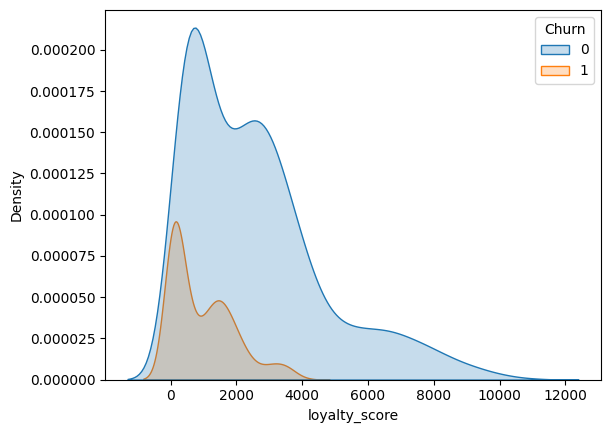

In [191]:
sns.kdeplot(data=df, x='loyalty_score', hue='Churn', fill=True)

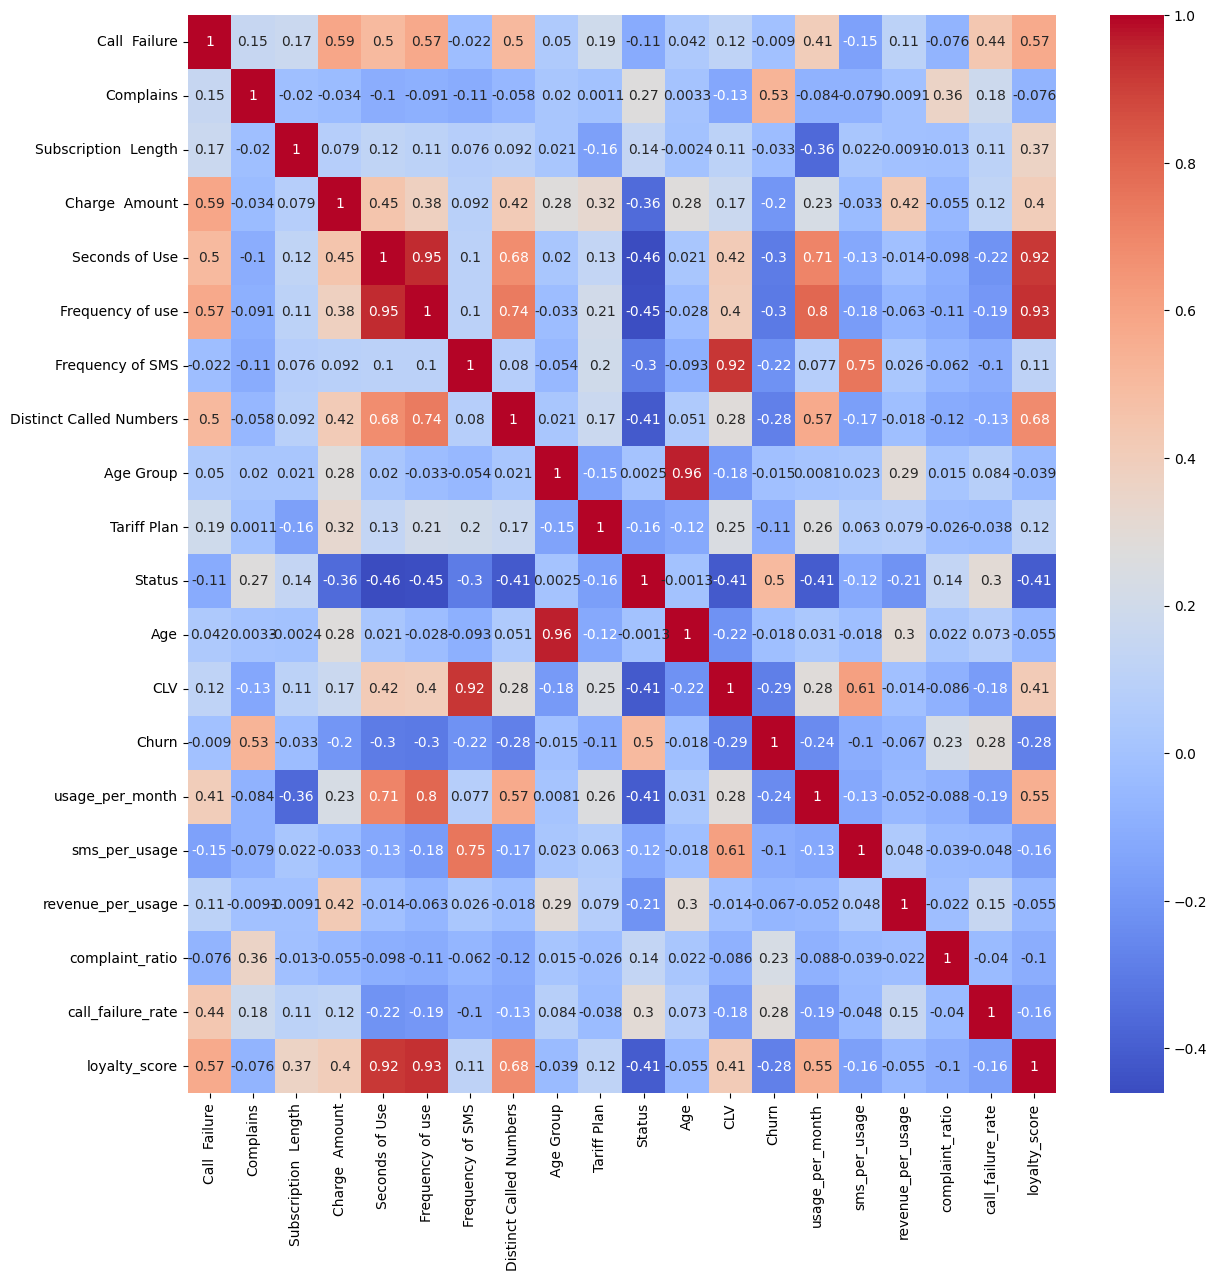

In [192]:

import seaborn as sns
import matplotlib.pyplot as plt

numeric_df = df.select_dtypes(include=['number'])

plt.figure(figsize=(14,14))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.show()

In [193]:
corr = df.corr(numeric_only=True)

# correlation with churn
corr['Churn'].sort_values()

Frequency of use          -0.303337
Seconds of Use            -0.298935
CLV                       -0.289144
loyalty_score             -0.282540
Distinct Called Numbers   -0.278867
usage_per_month           -0.243169
Frequency of SMS          -0.220754
Charge  Amount            -0.202305
Tariff Plan               -0.105853
sms_per_usage             -0.101724
revenue_per_usage         -0.066665
Subscription  Length      -0.032588
Age                       -0.017705
Age Group                 -0.014550
Call  Failure             -0.008987
complaint_ratio            0.234796
call_failure_rate          0.283363
Status                     0.498976
Complains                  0.532053
Churn                      1.000000
Name: Churn, dtype: float64

# MODEL BUILDING 

 logistic regression = baseline model

print(X_train.select_dtypes(include='interval').columns.tolist())

In [194]:

X = df.drop('Churn', axis=1)
y = df['Churn']


In [195]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

for col in X_train.select_dtypes(include='interval').columns:
    X_train[col] = X_train[col].apply(lambda x: x.mid)
    X_test[col] = X_test[col].apply(lambda x: x.mid)

here we using class_weight='balanced' beacuse intially without using that we observed that model follows class imbalanced  

handling class imbabalnce  Class imbalance = one category dominates the dataset, so the model may ignore the smaller class.so the model becomes biased toward it

We can  treat class imbalance in the baseline model because baseline model  by using in class_weight='balanced'

In [196]:
model = LogisticRegression(class_weight='balanced', max_iter=1000)



In [197]:
model.fit(X_train, y_train)

C:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

In [198]:
y_pred = model.predict(X_test)

In [199]:
accuracy = accuracy_score(y_test, y_pred)

print("Test Accuracy :", accuracy)

Test Accuracy : 0.8253968253968254


In [200]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.96      0.82      0.89       520
           1       0.50      0.83      0.62       110

    accuracy                           0.83       630
   macro avg       0.73      0.83      0.75       630
weighted avg       0.88      0.83      0.84       630



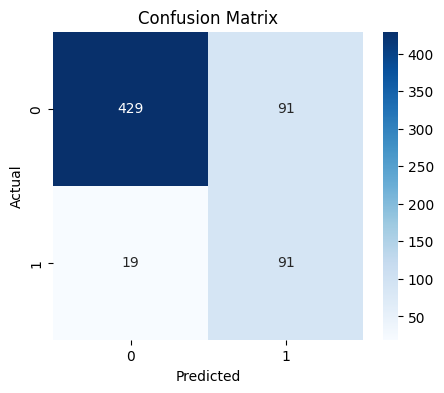

In [201]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [202]:
# Train accuracy
train_acc = model.score(X_train, y_train)

# Test accuracy
test_acc = model.score(X_test, y_test)

print("Train Accuracy :", train_acc)
print("Test Accuracy  :", test_acc)

Train Accuracy : 0.8468253968253968
Test Accuracy  : 0.8253968253968254


In [203]:
difference = train_acc - test_acc

print("Accuracy Difference :", difference)

if difference > 0.10:
    print("Model may be overfitting")

else:
    print("Model looks balanced")

Accuracy Difference : 0.021428571428571463
Model looks balanced


In [204]:
#previous imbalanced model report 
#accuracy : 0.8666666666666667

#                  precision    recall  f1-score   support
# 0 ( non churn)    0.89      0.95      0.92       520
# 1  ( churn)      0.68      0.45      0.54       110

# confusion matric 
  #             Predicted 0  	Predicted 1
#Actual 0	         496     	24
#Actual 1	          60	    50

#Train Accuracy : 0.9007936507936508
#Test Accuracy  : 0.8666666666666667

#Accuracy Difference : 0.03412698412698412
# Model looks balanced

In [205]:
# AFTER handling class imbalance 
#Train Accuracy : 0.8468253968253968
#Test Accuracy  : 0.8253968253968254

# Classification report 
#                  precision    recall  f1-score   support
# 0 ( non churn)    0.96      0.82      0.89       520
# 1  ( churn)      0.50      0.83      0.62       110

# confusion matric 
  #             Predicted 0  	Predicted 1
#Actual 0	         429     	91
#Actual 1	          19	    91

#Accuracy Difference :0.021428571428571463
# Model looks balanced

# main model random forest  classifier 

selected_features = [

    'Call  Failure',
    'Complains',
    'Subscription  Length',
    'Charge  Amount',
    'Seconds of Use',
    'Frequency of use',
    'Distinct Called Numbers',
    'CLV',
    'usage_per_month',
    'sms_per_usage',
    'revenue_per_usage',
    'complaint_ratio',
    'call_failure_rate',
    'loyalty_score'

]

In [206]:
X = df.drop('Churn', axis=1)

y = df['Churn']

In [207]:
X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y

)


In [208]:

model = RandomForestClassifier(

    n_estimators=200,
    max_depth=8,
    class_weight='balanced',
    random_state=42

)

In [209]:
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",8
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_

In [210]:
y_pred = model.predict(X_test)

In [211]:
accuracy = accuracy_score(y_test, y_pred)

print("Test Accuracy :", accuracy)

Test Accuracy : 0.9428571428571428


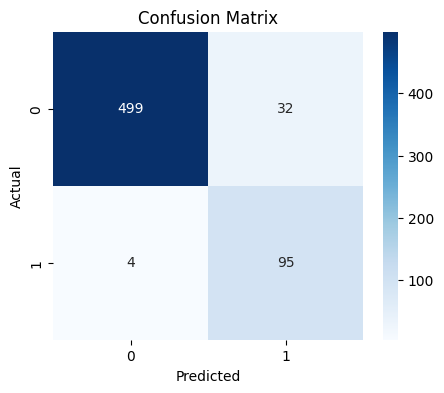

In [212]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [213]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.94      0.97       531
           1       0.75      0.96      0.84        99

    accuracy                           0.94       630
   macro avg       0.87      0.95      0.90       630
weighted avg       0.95      0.94      0.95       630



In [277]:
from sklearn.metrics import classification_report


# Train Predictions
y_train_pred = model.predict(X_train)


# Train Classification Report
print(

    classification_report(
        y_train,
        y_train_pred
    )

)

              precision    recall  f1-score   support

           0       1.00      0.95      0.97      2124
           1       0.80      0.99      0.88       396

    accuracy                           0.96      2520
   macro avg       0.90      0.97      0.93      2520
weighted avg       0.97      0.96      0.96      2520



# feature importance 

In [214]:
import pandas as pd

feature_importance = pd.Series(

    model.feature_importances_,
    index=X.columns

).sort_values(ascending=False)

print(feature_importance)

Status                     0.152483
Seconds of Use             0.109626
complaint_ratio            0.100077
Frequency of use           0.091494
Complains                  0.081422
loyalty_score              0.076593
CLV                        0.076246
usage_per_month            0.052363
Subscription  Length       0.047877
Frequency of SMS           0.041905
call_failure_rate          0.036260
Distinct Called Numbers    0.034940
sms_per_usage              0.019958
revenue_per_usage          0.019107
Age Group                  0.017547
Call  Failure              0.016358
Age                        0.016093
Charge  Amount             0.009112
Tariff Plan                0.000538
dtype: float64


In [215]:
# Train Accuracy
train_acc = model.score(X_train, y_train)

# Test Accuracy
test_acc = model.score(X_test, y_test)

print("Train Accuracy :", train_acc)
print("Test Accuracy  :", test_acc)

Train Accuracy : 0.9587301587301588
Test Accuracy  : 0.9428571428571428


In [216]:
difference = train_acc - test_acc

print("Accuracy Difference :", difference)

if difference > 0.10:

    print("Model may be overfitting")

else:

    print("Model looks balanced")


Accuracy Difference : 0.015873015873015928
Model looks balanced


# Strongest churn drivers

status
Complains,
Frequency of use,
Seconds of use,
Distinct called numbers,
CLV,
Subscription length,
Charge amount,
Call Failure,	
usage_per_month,
sms_per_usage,
,revenue_per_usage
,complaint_ratio,
call_failure_rate	
,loyalty_score

# creating segment on the  basis  of that feature 

In [284]:

df['risk_score'] = 0

# status 
df.loc[
    df['Status'] == 2,
    'risk_score'
] += 1



# 1. High Call Failure
df.loc[
    df['Call  Failure'] > df['Call  Failure'].median(),
    'risk_score'
] += 1


# 2. Complaints Present (0 = No, 1 = Yes)

df.loc[
    df['Complains'] == 1,
    'risk_score'
] += 1


# 3. Low Subscription Length
df.loc[
    df['Subscription  Length'] < df['Subscription  Length'].median(),
    'risk_score'
] += 1


# 4. High Charge Amount
df.loc[
    df['Charge  Amount'] > df['Charge  Amount'].median(),
    'risk_score'
] += 1


# 5. Low Seconds of Use
df.loc[
    df['Seconds of Use'] < df['Seconds of Use'].median(),
    'risk_score'
] += 1


# 6. Low Frequency of Use
df.loc[
    df['Frequency of use'] < df['Frequency of use'].median(),
    'risk_score'
] += 1


# 7. Low Distinct Called Numbers
df.loc[
    df['Distinct Called Numbers'] < df['Distinct Called Numbers'].median(),
    'risk_score'
] += 1


# 8. Low CLV
df.loc[
    df['CLV'] < df['CLV'].median(),
    'risk_score'
] += 1


# 9. Low Usage Per Month
df.loc[
    df['usage_per_month'] < df['usage_per_month'].median(),
    'risk_score'
] += 1


# 10. Low SMS Per Usage
df.loc[
    df['sms_per_usage'] < df['sms_per_usage'].median(),
    'risk_score'
] += 1


# 11. High Revenue Per Usage
df.loc[
    df['revenue_per_usage'] > df['revenue_per_usage'].median(),
    'risk_score'
] += 1


# 12. High Complaint Ratio
df.loc[
    df['complaint_ratio'] > df['complaint_ratio'].median(),
    'risk_score'
] += 1


# 13. High Call Failure Rate
df.loc[
    df['call_failure_rate'] > df['call_failure_rate'].median(),
    'risk_score'
] += 1


# 14. Low Loyalty Score
df.loc[
    df['loyalty_score'] < df['loyalty_score'].median(),
    'risk_score'
] += 1

# 15. status  Present (0 = inactive, 1 = active)

df.loc[
    df['Status'] == 0,
    'risk_score'
] += 1

In [285]:
def segment_customer(score):

    if score >= 10:
        return 'High Risk'

    elif score >= 5:
        return 'Medium Risk'

    else:
        return 'Low Risk'


df['customer_segment'] = df['risk_score'].apply(segment_customer)



In [286]:
print(df[['risk_score', 'customer_segment']].head())

   risk_score customer_segment
0           5      Medium Risk
1           7      Medium Risk
2           4         Low Risk
3           3         Low Risk
4           4         Low Risk


In [287]:
df.head()

,Call Failure,Complains,Subscription Length,Charge Amount,Seconds of Use,Frequency of use,Frequency of SMS,Distinct Called Numbers,Age Group,Tariff Plan,...,loyalty_score,risk_score,customer_segment,estimated_revenue_loss,retention_action,customer_health_score,health_segment,warning_score,early_warning_alert,root_cause
0,8,0,38,0,4370,71,5,17,3,1,...,2698,5,Medium Risk,197.640,Targeted Retention,95,Healthy,1,Stable,"[Low Social Interaction, Low Customer Value, H..."
1,0,0,39,0,318,5,7,4,2,1,...,195,7,Medium Risk,46.035,Targeted Retention,60,Moderate Risk,2,Moderate Risk,"[Low Frequency of Use, Low Usage Duration, Low..."
2,10,0,37,0,2453,60,359,24,3,1,...,2220,4,Low Risk,1536.520,Automated Campaign,85,Healthy,2,Moderate Risk,"[Low Usage Duration, High Call Failure, Low Mo..."
3,10,0,38,0,4198,66,1,35,1,1,...,2508,3,Low Risk,240.020,Automated Campaign,100,Healthy,1,Stable,"[High Call Failure, Low SMS Engagement, Poor N..."
4,3,0,38,0,2393,58,2,33,1,1,...,2204,4,Low Risk,145.805,Automated Campaign,90,Healthy,1,Stable,"[Low Usage Duration, Low Customer Value, Low M..."


In [221]:
# Get only High Risk customers

high_risk_customers = df[
    df['customer_segment'] == 'High Risk'
]

high_risk_customers.head()

,Call Failure,Complains,Subscription Length,Charge Amount,Seconds of Use,Frequency of use,Frequency of SMS,Distinct Called Numbers,Age Group,Tariff Plan,...,CLV,Churn,usage_per_month,sms_per_usage,revenue_per_usage,complaint_ratio,call_failure_rate,loyalty_score,risk_score,customer_segment
22,23,1,33,0,955,47,16,17,2,1,...,117.090,1,1.424242,0.333333,0.000000,0.020833,0.479167,1551,12,High Risk
40,11,0,27,0,700,25,10,7,2,1,...,77.625,0,0.925926,0.384615,0.000000,0.000000,0.423077,675,10,High Risk
49,3,0,9,1,1488,19,0,7,3,1,...,60.280,1,2.111111,0.000000,0.050000,0.000000,0.150000,171,10,High Risk
66,3,0,39,1,935,17,5,13,2,1,...,65.340,0,0.435897,0.277778,0.055556,0.000000,0.166667,663,10,High Risk
68,3,1,39,1,60,3,5,2,2,1,...,25.335,1,0.076923,1.250000,0.250000,0.250000,0.750000,117,11,High Risk


In [222]:
high_risk_customers.columns

Index(['Call  Failure', 'Complains', 'Subscription  Length', 'Charge  Amount',
       'Seconds of Use', 'Frequency of use', 'Frequency of SMS',
       'Distinct Called Numbers', 'Age Group', 'Tariff Plan', 'Status', 'Age',
       'CLV', 'Churn', 'usage_per_month', 'sms_per_usage', 'revenue_per_usage',
       'complaint_ratio', 'call_failure_rate', 'loyalty_score', 'risk_score',
       'customer_segment'],
      dtype='object')

In [223]:
medium_risk_customers = df[
    df['customer_segment'] == 'Medium Risk'
]

medium_risk_customers.head()

,Call Failure,Complains,Subscription Length,Charge Amount,Seconds of Use,Frequency of use,Frequency of SMS,Distinct Called Numbers,Age Group,Tariff Plan,...,CLV,Churn,usage_per_month,sms_per_usage,revenue_per_usage,complaint_ratio,call_failure_rate,loyalty_score,risk_score,customer_segment
0,8,0,38,0,4370,71,5,17,3,1,...,197.640,0,1.868421,0.069444,0.000000,0.0,0.111111,2698,5,Medium Risk
1,0,0,39,0,318,5,7,4,2,1,...,46.035,0,0.128205,1.166667,0.000000,0.0,0.000000,195,6,Medium Risk
5,11,0,38,1,3775,82,32,28,3,1,...,282.280,0,2.157895,0.385542,0.012048,0.0,0.132530,3116,5,Medium Risk
6,4,0,38,0,2360,39,285,18,3,1,...,1235.960,0,1.026316,7.125000,0.000000,0.0,0.100000,1482,6,Medium Risk
9,7,0,38,1,4515,83,2,25,3,1,...,191.920,0,2.184211,0.023810,0.011905,0.0,0.083333,3154,5,Medium Risk


# REVENUE LOSS ESTIMATION

In [224]:
df['estimated_revenue_loss'] = (

    df['CLV'] *

    (1 + (df['Charge  Amount'] / 10))

)

In [225]:
df['estimated_revenue_loss'].head()

0     197.640
1      46.035
2    1536.520
3     240.020
4     145.805
Name: estimated_revenue_loss, dtype: float64

In [226]:
high_risk_customers = df[
    df['customer_segment'] == 'High Risk'
]

In [227]:
total_loss = high_risk_customers[
    'estimated_revenue_loss'
].sum()

print("Total Potential Revenue Loss :", total_loss)

Total Potential Revenue Loss : 56433.787000000004


In [228]:
top_customers = high_risk_customers.sort_values(

    by='estimated_revenue_loss',
    ascending=False

)

top_customers.head()

,Call Failure,Complains,Subscription Length,Charge Amount,Seconds of Use,Frequency of use,Frequency of SMS,Distinct Called Numbers,Age Group,Tariff Plan,...,Churn,usage_per_month,sms_per_usage,revenue_per_usage,complaint_ratio,call_failure_rate,loyalty_score,risk_score,customer_segment,estimated_revenue_loss
2688,9,0,30,3,1735,48,232,17,3,2,...,0,1.600000,4.734694,0.061224,0.0,0.183673,1440,10,High Risk,1299.116
2288,10,0,33,3,1700,44,210,17,3,2,...,0,1.333333,4.666667,0.066667,0.0,0.222222,1452,10,High Risk,1182.688
2938,11,0,34,3,1620,48,208,14,3,2,...,0,1.411765,4.244898,0.061224,0.0,0.224490,1632,10,High Risk,1168.336
2188,12,0,31,3,1680,45,205,15,3,2,...,0,1.451613,4.456522,0.065217,0.0,0.260870,1395,10,High Risk,1155.700
2488,11,0,32,2,1800,50,211,18,3,2,...,0,1.562500,4.137255,0.039216,0.0,0.215686,1600,10,High Risk,1101.600


<Axes: xlabel='customer_segment', ylabel='estimated_revenue_loss'>

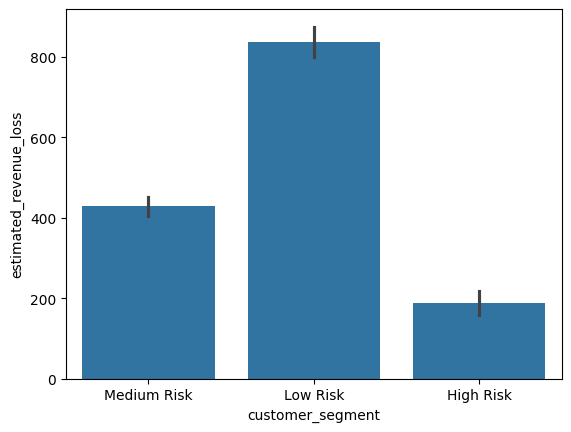

In [229]:
sns.barplot(

    x='customer_segment',
    y='estimated_revenue_loss',
    data=df

)

# ROOT CAUSE 

In [288]:

def identify_root_causes(row):

    causes = []

    # 1. Complaints
    if row['Status'] == 2:
        causes.append('Non active')

    
    # 1. Complaints
    if row['Complains'] == 1:
        causes.append('High Complaints')


    # 2. Low Frequency of Use
    if row['Frequency of use'] < df['Frequency of use'].median():
        causes.append('Low Frequency of Use')


    # 3. Low Seconds of Use
    if row['Seconds of Use'] < df['Seconds of Use'].median():
        causes.append('Low Usage Duration')


    # 4. Low Distinct Called Numbers
    if row['Distinct Called Numbers'] < df['Distinct Called Numbers'].median():
        causes.append('Low Social Interaction')


    # 5. Low CLV
    if row['CLV'] < df['CLV'].median():
        causes.append('Low Customer Value')


    # 6. Low Subscription Length
    if row['Subscription  Length'] < df['Subscription  Length'].median():
        causes.append('Short Subscription Duration')


    # 7. High Charge Amount
    # Charge Amount ranges from 0–9
    if row['Charge  Amount'] >= 7:
        causes.append('High Pricing Tier')


    # 8. High Call Failure
    if row['Call  Failure'] > df['Call  Failure'].median():
        causes.append('High Call Failure')


    # 9. Low Usage Per Month
    if row['usage_per_month'] < df['usage_per_month'].median():
        causes.append('Low Monthly Usage')


    # 10. Low SMS Per Usage
    if row['sms_per_usage'] < df['sms_per_usage'].median():
        causes.append('Low SMS Engagement')


    # 11. High Revenue Per Usage
    if row['revenue_per_usage'] > df['revenue_per_usage'].median():
        causes.append('Low Value for Money')


    # 12. High Complaint Ratio
    if row['complaint_ratio'] > df['complaint_ratio'].median():
        causes.append('Frequent Complaints')


    # 13. High Call Failure Rate
    if row['call_failure_rate'] > df['call_failure_rate'].median():
        causes.append('Poor Network Experience')


    # 14. Low Loyalty Score
    if row['loyalty_score'] < df['loyalty_score'].median():
        causes.append('Low Customer Loyalty')


    return causes




In [289]:


df['root_cause'] = df.apply(

    identify_root_causes,
    axis=1

)




In [290]:
df[[

    'root_cause'

]].head()

,root_cause
0,"[Low Social Interaction, Low Customer Value, H..."
1,"[Non active, Low Frequency of Use, Low Usage D..."
2,"[Low Usage Duration, High Call Failure, Low Mo..."
3,"[High Call Failure, Low SMS Engagement, Poor N..."
4,"[Low Usage Duration, Low Customer Value, Low M..."


In [292]:
df.head()

,Call Failure,Complains,Subscription Length,Charge Amount,Seconds of Use,Frequency of use,Frequency of SMS,Distinct Called Numbers,Age Group,Tariff Plan,...,risk_score,customer_segment,estimated_revenue_loss,retention_action,customer_health_score,health_segment,warning_score,early_warning_alert,root_cause,root_cause
0,8,0,38,0,4370,71,5,17,3,1,...,5,Medium Risk,197.640,Targeted Retention,95,Healthy,1,Stable,"[Low Social Interaction, Low Customer Value, H...","[Low Social Interaction, Low Customer Value, H..."
1,0,0,39,0,318,5,7,4,2,1,...,7,Medium Risk,46.035,Targeted Retention,60,Moderate Risk,2,Moderate Risk,"[Low Frequency of Use, Low Usage Duration, Low...","[Non active, Low Frequency of Use, Low Usage D..."
2,10,0,37,0,2453,60,359,24,3,1,...,4,Low Risk,1536.520,Automated Campaign,85,Healthy,2,Moderate Risk,"[Low Usage Duration, High Call Failure, Low Mo...","[Low Usage Duration, High Call Failure, Low Mo..."
3,10,0,38,0,4198,66,1,35,1,1,...,3,Low Risk,240.020,Automated Campaign,100,Healthy,1,Stable,"[High Call Failure, Low SMS Engagement, Poor N...","[High Call Failure, Low SMS Engagement, Poor N..."
4,3,0,38,0,2393,58,2,33,1,1,...,4,Low Risk,145.805,Automated Campaign,90,Healthy,1,Stable,"[Low Usage Duration, Low Customer Value, Low M...","[Low Usage Duration, Low Customer Value, Low M..."


 # Retention Optimization System

In [234]:
def retention_strategy(row):

    # VIP Customers
    if (
        row['customer_segment'] == 'High Risk'
       
    ):
        return 'VIP Retention'


    # Medium Priority
    elif (
        row['customer_segment'] == 'Medium Risk'
    ):
        return 'Targeted Retention'


    # Automated Campaigndf
    elif (
        row['customer_segment'] == 'Low Risk'
        
    ):
        return 'Automated Campaign'


    # Stable Customers
    else:
        return 'Low Priority'


df['retention_action'] = df.apply(

    retention_strategy,
    axis=1

)

In [235]:
df.head()

,Call Failure,Complains,Subscription Length,Charge Amount,Seconds of Use,Frequency of use,Frequency of SMS,Distinct Called Numbers,Age Group,Tariff Plan,...,sms_per_usage,revenue_per_usage,complaint_ratio,call_failure_rate,loyalty_score,risk_score,customer_segment,estimated_revenue_loss,risk_drivers,retention_action
0,8,0,38,0,4370,71,5,17,3,1,...,0.069444,0.0,0.0,0.111111,2698,5,Medium Risk,197.640,"[Low Network/Social Interaction, Low Customer ...",Targeted Retention
1,0,0,39,0,318,5,7,4,2,1,...,1.166667,0.0,0.0,0.000000,195,6,Medium Risk,46.035,"[Low Frequency of Use, Low Usage Duration, Low...",Targeted Retention
2,10,0,37,0,2453,60,359,24,3,1,...,5.885246,0.0,0.0,0.163934,2220,4,Low Risk,1536.520,"[Low Usage Duration, High Call Failure, Low Mo...",Automated Campaign
3,10,0,38,0,4198,66,1,35,1,1,...,0.014925,0.0,0.0,0.149254,2508,3,Low Risk,240.020,"[High Call Failure, Low SMS Engagement, Poor N...",Automated Campaign
4,3,0,38,0,2393,58,2,33,1,1,...,0.033898,0.0,0.0,0.050847,2204,4,Low Risk,145.805,"[Low Usage Duration, Low Customer Value, Low M...",Automated Campaign


In [236]:
df.tail()

,Call Failure,Complains,Subscription Length,Charge Amount,Seconds of Use,Frequency of use,Frequency of SMS,Distinct Called Numbers,Age Group,Tariff Plan,...,sms_per_usage,revenue_per_usage,complaint_ratio,call_failure_rate,loyalty_score,risk_score,customer_segment,estimated_revenue_loss,risk_drivers,retention_action
3145,21,0,19,2,6697,147,92,44,2,2,...,0.621622,0.013514,0.000000,0.141892,2793,5,Medium Risk,866.376,"[Short Subscription Duration, High Call Failur...",Targeted Retention
3146,17,0,17,1,9237,177,80,42,5,1,...,0.449438,0.005618,0.000000,0.095506,3009,6,Medium Risk,287.331,"[Short Subscription Duration, High Call Failur...",Targeted Retention
3147,13,0,18,4,3157,51,38,21,3,1,...,0.730769,0.076923,0.000000,0.250000,918,7,Medium Risk,392.448,"[Low Frequency of Use, Short Subscription Dura...",Targeted Retention
3148,7,0,11,2,4695,46,222,12,3,1,...,4.723404,0.042553,0.000000,0.148936,506,8,Medium Risk,1293.168,"[Low Frequency of Use, Low Network/Social Inte...",Targeted Retention
3149,8,1,11,2,1792,25,7,9,3,1,...,0.269231,0.076923,0.038462,0.307692,275,13,High Risk,120.816,"[High Complaints, Low Frequency of Use, Low Us...",VIP Retention


# CUSTOMER HEALTH SCORE

In [237]:
df['customer_health_score'] = 100

In [293]:
df.loc[
    df['Status'] == 2,
    'customer_health_score'
] -= 20

In [294]:
df.loc[
    df['Complains'] == 1,
    'customer_health_score'
] -= 20

In [295]:
df.loc[
    df['call_failure_rate']
    > df['call_failure_rate'].median(),

    'customer_health_score'
] -= 15

In [296]:
df.loc[
    df['usage_per_month']
    < df['usage_per_month'].median(),

    'customer_health_score'
] -= 20

In [297]:
df.loc[
    df['loyalty_score']
    < df['loyalty_score'].median(),

    'customer_health_score'
] -= 20

In [298]:
df.loc[
    df['Frequency of use']
    < df['Frequency of use'].median(),

    'customer_health_score'
] -= 10

In [299]:
df.loc[
    df['Subscription  Length']
    > df['Subscription  Length'].median(),

    'customer_health_score'
] += 10

In [300]:
df.loc[
    df['CLV'] > df['CLV'].median(),
    'customer_health_score'
] += 10

In [301]:
df['customer_health_score'] = df[
    'customer_health_score'
].clip(0, 100)

In [302]:
df['customer_health_score'] = round(

    df['customer_health_score'],
    1

)

In [303]:
def health_segment(score):

    if score >= 80:
        return 'Healthy'

    elif score >= 50:
        return 'Moderate Risk'

    else:
        return 'Critical Risk'


df['health_segment'] = df[
    'customer_health_score'
].apply(health_segment)

In [304]:
df[[

    'customer_health_score',
    'health_segment'

]].head()

,customer_health_score,health_segment
0,90,Healthy
1,0,Critical Risk
2,70,Moderate Risk
3,100,Healthy
4,80,Healthy


In [305]:
df.head()

,Call Failure,Complains,Subscription Length,Charge Amount,Seconds of Use,Frequency of use,Frequency of SMS,Distinct Called Numbers,Age Group,Tariff Plan,...,risk_score,customer_segment,estimated_revenue_loss,retention_action,customer_health_score,health_segment,warning_score,early_warning_alert,root_cause,root_cause
0,8,0,38,0,4370,71,5,17,3,1,...,5,Medium Risk,197.640,Targeted Retention,90,Healthy,1,Stable,"[Low Social Interaction, Low Customer Value, H...","[Low Social Interaction, Low Customer Value, H..."
1,0,0,39,0,318,5,7,4,2,1,...,7,Medium Risk,46.035,Targeted Retention,0,Critical Risk,2,Moderate Risk,"[Low Frequency of Use, Low Usage Duration, Low...","[Non active, Low Frequency of Use, Low Usage D..."
2,10,0,37,0,2453,60,359,24,3,1,...,4,Low Risk,1536.520,Automated Campaign,70,Moderate Risk,2,Moderate Risk,"[Low Usage Duration, High Call Failure, Low Mo...","[Low Usage Duration, High Call Failure, Low Mo..."
3,10,0,38,0,4198,66,1,35,1,1,...,3,Low Risk,240.020,Automated Campaign,100,Healthy,1,Stable,"[High Call Failure, Low SMS Engagement, Poor N...","[High Call Failure, Low SMS Engagement, Poor N..."
4,3,0,38,0,2393,58,2,33,1,1,...,4,Low Risk,145.805,Automated Campaign,80,Healthy,1,Stable,"[Low Usage Duration, Low Customer Value, Low M...","[Low Usage Duration, Low Customer Value, Low M..."


# EARLY WARNING SYSTEM

In [250]:
df['warning_score'] = 0

In [251]:
df.loc[
    df['usage_per_month']
    < df['usage_per_month'].median(),

    'warning_score'
] += 1

In [306]:
df.loc[
    df['Status'] == 2,

    'warning_score'
] += 1

In [307]:
df.loc[
    df['Complains'] == 1,

    'warning_score'
] += 1

In [308]:
df.loc[
    df['call_failure_rate']
    > df['call_failure_rate'].median(),

    'warning_score'
] += 1

In [309]:
df.loc[
    df['loyalty_score']
    < df['loyalty_score'].median(),

    'warning_score'
] += 1

In [310]:
def generate_alert(score):

    if score >= 3:
        return ' High Churn Alert'

    elif score >= 2:
        return ' Moderate Risk'

    else:
        return ' Stable'


df['early_warning_alert'] = df[
    'warning_score'
].apply(generate_alert)

In [311]:
df['early_warning_alert'].value_counts(
    normalize=True
)*100


#early_warning_alert
#Stable              1464
#Moderate Risk        896
#High Churn Alert     790
#Name: count, dtype: int64

early_warning_alert
High Churn Alert    53.587302
Stable              25.365079
Moderate Risk       21.047619
Name: proportion, dtype: float64

In [312]:
df.head()

,Call Failure,Complains,Subscription Length,Charge Amount,Seconds of Use,Frequency of use,Frequency of SMS,Distinct Called Numbers,Age Group,Tariff Plan,...,risk_score,customer_segment,estimated_revenue_loss,retention_action,customer_health_score,health_segment,warning_score,early_warning_alert,root_cause,root_cause
0,8,0,38,0,4370,71,5,17,3,1,...,5,Medium Risk,197.640,Targeted Retention,90,Healthy,2,Moderate Risk,"[Low Social Interaction, Low Customer Value, H...","[Low Social Interaction, Low Customer Value, H..."
1,0,0,39,0,318,5,7,4,2,1,...,7,Medium Risk,46.035,Targeted Retention,0,Critical Risk,4,High Churn Alert,"[Low Frequency of Use, Low Usage Duration, Low...","[Non active, Low Frequency of Use, Low Usage D..."
2,10,0,37,0,2453,60,359,24,3,1,...,4,Low Risk,1536.520,Automated Campaign,70,Moderate Risk,3,High Churn Alert,"[Low Usage Duration, High Call Failure, Low Mo...","[Low Usage Duration, High Call Failure, Low Mo..."
3,10,0,38,0,4198,66,1,35,1,1,...,3,Low Risk,240.020,Automated Campaign,100,Healthy,2,Moderate Risk,"[High Call Failure, Low SMS Engagement, Poor N...","[High Call Failure, Low SMS Engagement, Poor N..."
4,3,0,38,0,2393,58,2,33,1,1,...,4,Low Risk,145.805,Automated Campaign,80,Healthy,1,Stable,"[Low Usage Duration, Low Customer Value, Low M...","[Low Usage Duration, Low Customer Value, Low M..."


# Churn Trend Analysis

In [258]:
Churn_Trend = pd.crosstab(

    df['customer_segment'],
    df['Churn'],

    normalize='index'

) * 100

print(Churn_Trend)

Churn                     0          1
customer_segment                      
High Risk         52.000000  48.000000
Low Risk          98.105263   1.894737
Medium Risk       82.473684  17.526316


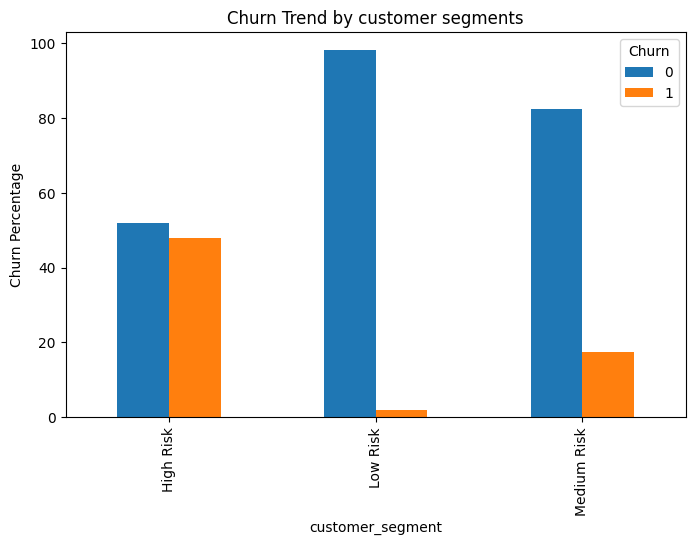

In [259]:
Churn_Trend.plot(

    kind='bar',
    figsize=(8,5)

)

plt.ylabel("Churn Percentage")
plt.title("Churn Trend by customer segments")

plt.show()

In [275]:
df.shape

(3150, 29)

In [276]:
df.columns

Index(['Call  Failure', 'Complains', 'Subscription  Length', 'Charge  Amount',
       'Seconds of Use', 'Frequency of use', 'Frequency of SMS',
       'Distinct Called Numbers', 'Age Group', 'Tariff Plan', 'Status', 'Age',
       'CLV', 'Churn', 'usage_per_month', 'sms_per_usage', 'revenue_per_usage',
       'complaint_ratio', 'call_failure_rate', 'loyalty_score', 'risk_score',
       'customer_segment', 'estimated_revenue_loss', 'retention_action',
       'customer_health_score', 'health_segment', 'warning_score',
       'early_warning_alert', 'root_cause '],
      dtype='object')

# recommendation strategy 

In [313]:
#Feature             	        Problem Detected                      	Recommendation Strategy
# non active                    low engagement / losing interest                Personalized engagement campaigns, loyalty rewards, proactive customer interaction
#Complains	                    customer dissatisfaction	                    Priority customer support, faster issue resolution, feedback follow-up
#Frequency of use	            low engagement	                                personalized offers, engagement campaigns, usage reminders
#Seconds of use      	        reduced activity	                            provide bonus talktime/data plans to increase activity
#Distinct Called Numbers        low social interaction	                        suggest family/friends calling packs
#CLV	                        high-value customer at risk	                    VIP retention program, dedicated relationship manager
#Subscription Length 	        short customer relationship         	        onboarding campaigns, welcome rewards, loyalty education
#Charge Amount	                expensive plan dissatisfaction	                recommend suitable lower-cost or personalized plans
#Call Failure	                poor service quality	                        improve network/service quality in affected regions
#usage_per_month	            declining usage trend	                        proactive engagement campaigns and retention offers
#sms_per_usage	                low communication engagement	                SMS bundles/promotional communication offers
#revenue_per_usage	            paying more but using less	                    optimize pricing plans for better perceived value
#complaint_ratio	            frequent complaints vs engagement	            urgent customer care intervention
#call_failure_rate	            repeated service failure	                    technical issue resolution and network optimization
#loyalty_score	                weak customer loyalty	                        loyalty rewards, cashback, retention incentives

# validation 

Q1 Does model correctly identify churners? =  yes with having recall of 96% 

 Q2 Are identified churn drivers logically meaningful ? : yes i think thses all are churn driver in telecom : 'Call  Failure', 'Complains', 'Subscription  Length', 'Charge  Amount',
       'Seconds of Use', 'Frequency of use', 'Frequency of SMS',
       'Distinct Called Numbers', '', 'Tariff Plan', ',
       'CLV', '', 'usage_per_month', 'sms_per_usage', 'revenue_per_usage',
       'complaint_ratio', 'call_failure_rate', 'loyalty_score


Q3 Does the system help reduce revenue loss? yes it identifies each customer revenue loss with their churn risk , cause & here i attach each cause recoomendation strategy 

Q4 Does risk scoring separate customers properly ? yes it seperate each customer perfectly 

Q5 Can you explain WHY predictions happen? preduiction happen with help of all feature whcih are identified by model 

Q6 Does model perform consistently? yes train reacll is 99% v/s test recal is 96 % 

Q7 Does system identify churn BEFORE actual churn? yes if we monitor continoiusly early warning score then it helps us tro identify churners 

Q8 Does project support business decisions? yes my model help in taking buiseness decsion with help of customer segments + retention action + loyalty score ( customer value ) 

# Project Conclusion

This project successfully transformed a traditional telecom churn prediction model into an industry-oriented customer retention intelligence system by combining machine learning, business analytics, and actionable decision-making. The system not only predicts customers at risk of churn with high recall performance but also identifies the underlying behavioral factors contributing to churn, such as reduced service usage, shorter subscription tenure, increased complaints, lower engagement, and declining customer lifetime value (CLV).

Beyond prediction, the project focused on solving real business problems by introducing customer risk segmentation, churn driver analysis, revenue-at-risk estimation, customer health scoring, and retention strategy recommendations. This enabled the model to function as an early-warning system capable of helping telecom companies proactively identify high-risk customers and take targeted retention actions before actual churn occurs.

The analysis revealed that customer engagement metrics such as frequency of use, seconds of use, SMS activity, and distinct called numbers were among the strongest indicators of retention, while complaint behavior and pricing-related factors significantly influenced churn risk. Additionally, tenure-based behavioral analysis highlighted important customer lifecycle transitions and loyalty stabilization patterns within specific subscription periods.

Overall, the project demonstrates how data science can move beyond predictive modeling to support strategic business decision-making. By integrating explainable analytics, business-driven feature engineering, and actionable retention intelligence, the system provides a scalable framework that can help telecom companies improve customer retention, reduce revenue leakage, optimize retention campaigns, and enhance long-term customer value.

In [278]:
df_original = df.loc[
    :,
    'Call  Failure':'loyalty_score'
]


In [281]:
df_business = df.loc[
    :,
    'risk_score':'root_cause '
]


In [282]:

df_original.to_csv(
    " Churn original_features_dataset.csv",
    index=False
)

In [283]:
df_business.to_csv(
    " Churn business_intelligence_dataset.csv",
    index=False
)
